In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

import os

In [3]:
#disk = 'L:'# disk is Elements on adour


disk = 'C:'
date = '0211'

#data_path = f'{disk}/Share_hublot/Data'
data_path = f'C:/Users/Vasco Zanchi/Desktop/Saguenay2024'

daily_drone_data_path = f'{data_path}/{date}/Drones'

velocity_field_path = f'{daily_drone_data_path}/exact_solution_real_field_stereo_0211_2024_rectangular_grid.h5'

# traitement stéphane : postitions des fractures (obtenue avec divergence du champ de vitesses)
fractures_positions_path = f'{daily_drone_data_path}/Results/fracture_positions.pkl'

In [4]:
with open(fractures_positions_path, 'rb') as file:
    fractures_positions_data = pickle.load(file)

In [5]:
path_dict2save = f'{daily_drone_data_path}/Results/traitement_vasco/dict_results_frac_detrendvz.pkl'
if os.path.exists(path_dict2save):
    with open(path_dict2save, 'rb') as file:
        dict_frac = pickle.load(file)


(0.0, 0.025)

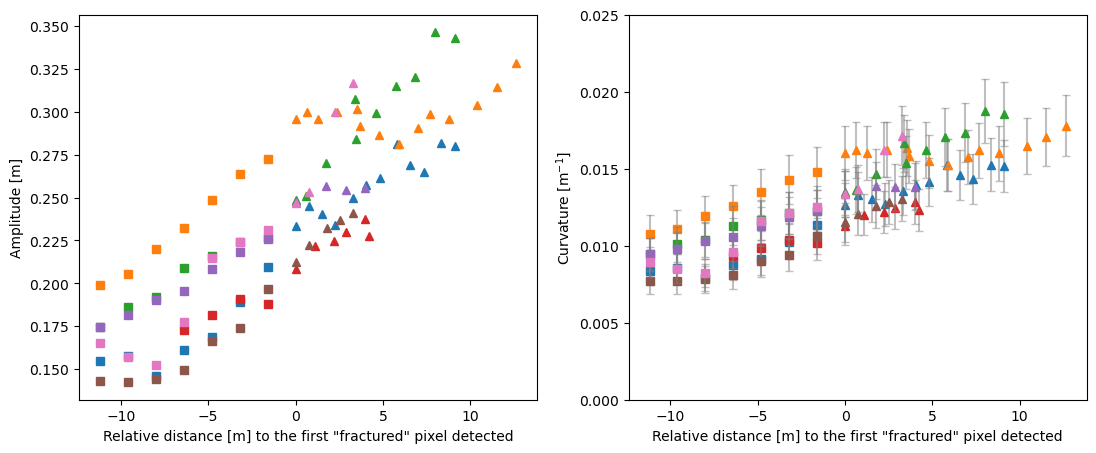

In [6]:
#array_frac_id = np.array(dict_frac['lambda_byhand']['list_frac_id'])
#array_wavelength = np.array(dict_frac['lambda_byhand']['wavelength'])

facq_x = 1.25

wavelength = 27 # m
wavelength_err = 1.5 # m

wavenumber = 2*np.pi/wavelength
wavenumber_err = 2*np.pi * wavelength_err/(wavelength**2)


fig, axs = plt.subplots(1,2, figsize=(13,5))


colors = ['tab:blue','tab:orange','tab:green','tab:red','tab:purple','tab:brown','tab:pink','tab:gray','tab:olive','tab:cyan']



ct = 0
for k in dict_frac:
    if 'single_frac' in k:
        coord_onfracline_cassee = dict_frac[k]['coord_onfracline_cassee']
        coord_onfracline_noncassee = dict_frac[k]['coord_onfracline_noncassee']
        array_amplitudes_frac = dict_frac[k]['array_amplitudes_frac']
        array_amplitudes_ref_noncassee = dict_frac[k]['array_amplitudes_ref_noncassee']

        #wave_period_sec = dict_frac[k]['wave_period_sec']




        axs[0].plot(coord_onfracline_noncassee * (1/facq_x), array_amplitudes_ref_noncassee,'s',color=colors[ct])
        axs[0].plot(coord_onfracline_cassee * (1/facq_x), array_amplitudes_frac,'^',color=colors[ct])

        axs[0].set_ylabel('Amplitude [m]')
        axs[0].set_xlabel('Relative distance [m] to the first "fractured" pixel detected')

        ######################

        #wavelength = array_wavelength[array_frac_id==k][0]


        array_kappa_frac = np.array(array_amplitudes_frac) * wavenumber**2
        array_kappa_noncassee = np.array(array_amplitudes_ref_noncassee) * wavenumber**2

        array_kappa_frac_err = np.array(array_amplitudes_frac) * (2 * wavenumber * wavenumber_err)
        array_kappa_noncassee_err = np.array(array_amplitudes_ref_noncassee) * (2 * wavenumber * wavenumber_err)

        axs[1].errorbar(coord_onfracline_cassee * (1/facq_x), array_kappa_frac, yerr=array_kappa_frac_err, linestyle='', ecolor='gray', capsize=3, marker='', alpha=0.5)
        axs[1].errorbar(coord_onfracline_noncassee * (1/facq_x), array_kappa_noncassee, yerr=array_kappa_noncassee_err, linestyle='', ecolor='gray', capsize=3, marker='', alpha=0.5)
        
        
        axs[1].plot(coord_onfracline_noncassee * (1/facq_x), array_kappa_noncassee,'s',color=colors[ct])
        axs[1].plot(coord_onfracline_cassee * (1/facq_x), array_kappa_frac,'^',color=colors[ct])

        axs[1].set_ylabel('Curvature [m$^{-1}$]')
        axs[1].set_xlabel('Relative distance [m] to the first "fractured" pixel detected')





        ct+=1

axs[1].set_ylim(0,0.025)
#axs[1].loglog()

In [7]:
array_kappa_noncassee_err

array([0.00138913, 0.00134787, 0.00129281, 0.00106659, 0.00091673,
       0.00094631, 0.0009944 ])

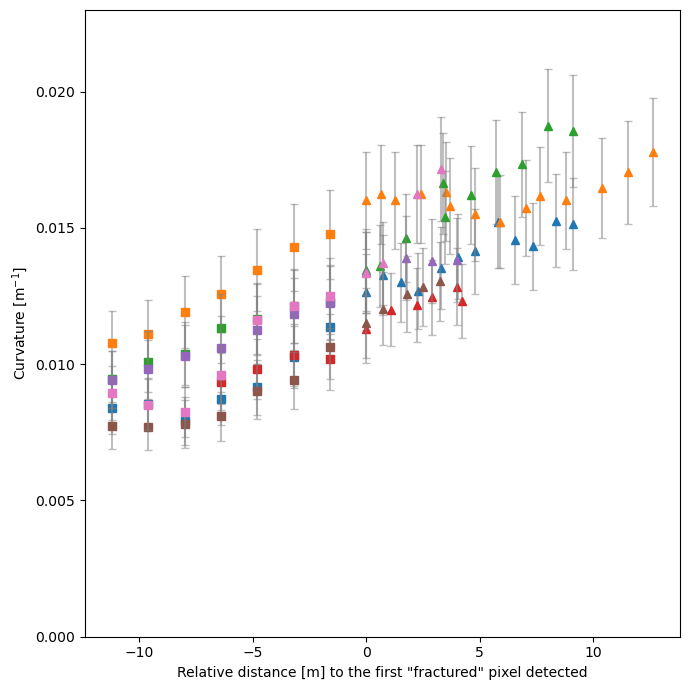

In [8]:

fig, ax = plt.subplots(figsize=(7,7))


ct = 0
for k in dict_frac:
    if 'single_frac' in k:
        coord_onfracline_cassee = dict_frac[k]['coord_onfracline_cassee']
        coord_onfracline_noncassee = dict_frac[k]['coord_onfracline_noncassee']
        array_amplitudes_frac = dict_frac[k]['array_amplitudes_frac']
        array_amplitudes_ref_noncassee = dict_frac[k]['array_amplitudes_ref_noncassee']


        array_kappa_frac = np.array(array_amplitudes_frac) * wavenumber**2
        array_kappa_noncassee = np.array(array_amplitudes_ref_noncassee) * wavenumber**2

        array_kappa_frac_err = np.array(array_amplitudes_frac) * (2 * wavenumber * wavenumber_err)
        array_kappa_noncassee_err = np.array(array_amplitudes_ref_noncassee) * (2 * wavenumber * wavenumber_err)

        ax.errorbar(coord_onfracline_cassee * (1/facq_x), array_kappa_frac, yerr=array_kappa_frac_err, linestyle='', ecolor='gray', capsize=3, marker='', alpha=0.5)
        ax.errorbar(coord_onfracline_noncassee * (1/facq_x), array_kappa_noncassee, yerr=array_kappa_noncassee_err, linestyle='', ecolor='gray', capsize=3, marker='', alpha=0.5)
        
        
        ax.plot(coord_onfracline_noncassee * (1/facq_x), array_kappa_noncassee,'s',color=colors[ct])
        ax.plot(coord_onfracline_cassee * (1/facq_x), array_kappa_frac,'^',color=colors[ct])

        ax.set_ylabel('Curvature [m$^{-1}$]')
        ax.set_xlabel('Relative distance [m] to the first "fractured" pixel detected')





        ct+=1

ax.set_ylim(0,0.023)
fig.tight_layout()
fig.savefig('C:/Users/Vasco Zanchi/Desktop/presentations/reunions_hebdo/figures_data_article/fig_finale_curvatures_sevenfrac.pdf', dpi=600)

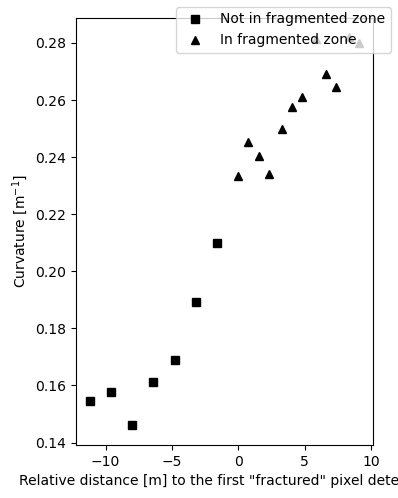

In [9]:
k = 'dict_single_frac_yind23_xind28'

coord_onfracline_cassee = dict_frac[k]['coord_onfracline_cassee']
coord_onfracline_noncassee = dict_frac[k]['coord_onfracline_noncassee']
array_amplitudes_frac = dict_frac[k]['array_amplitudes_frac']
array_amplitudes_ref_noncassee = dict_frac[k]['array_amplitudes_ref_noncassee']

fig, ax= plt.subplots(figsize=(4,5))
ax.errorbar(coord_onfracline_noncassee * (1/facq_x), array_amplitudes_ref_noncassee, linestyle='', marker='s', color='k', label='Not in fragmented zone')
ax.errorbar(coord_onfracline_cassee * (1/facq_x), array_amplitudes_frac, linestyle='', marker='^', color='k', label='In fragmented zone')


ax.set_ylabel('Curvature [m$^{-1}$]')
ax.set_xlabel('Relative distance [m] to the first "fractured" pixel detected')





ct+=1

#ax.set_ylim(0,0.023)
fig.legend()
fig.tight_layout()
fig.savefig('C:/Users/Vasco Zanchi/Desktop/presentations/reunions_hebdo/figures_data_article/example_amplitude_vs_coordalongfrac.pdf', dpi=600)